# 1. Statistical Mistakes



## 1.1. Inadecuate Control

Imagine we want to test whether a short training program improves participants’ performance on a task. People often get better simply from practicing the task, even without any training. If we measure only one group before and after the program, we might wrongly conclude that the training worked. By including a proper control group, we can see whether improvements are truly due to the training or just to practice over time.

Example: Spurious intervention effect without a control group

We simulate:

Practice effect → everyone improves slightly over time.

Training → actually has no real effect.

Without a control group → looks like training works.

With a control group → shows the truth.

**Step 1 — Simulate data**

In [ ]:
set.seed(123)

n <- 50  # participants per group

# baseline ability
baseline_treatment <- rnorm(n, mean = 50, sd = 10)
baseline_control   <- rnorm(n, mean = 50, sd = 10)

# PRACTICE EFFECT (everyone improves just by repeating task)
practice_effect <- 5

# TRUE training effect (set to 0 → intervention actually does nothing)
true_training_effect <- 0

# post scores
post_treatment <- baseline_treatment + practice_effect + true_training_effect + rnorm(n,0,3)
post_control   <- baseline_control + practice_effect + rnorm(n,0,3)


**Step 2 — What happens with NO control group (bad design)**


In [ ]:
t.test(post_treatment, baseline_treatment, paired = TRUE)


**Step 3 — Add a proper control group (good design)**

In [ ]:
change_treatment <- post_treatment - baseline_treatment
change_control   <- post_control - baseline_control

t.test(change_treatment, change_control)


**Step 4 — Visualise**

In [ ]:
boxplot(change_treatment, change_control,
        names = c("Treatment", "Control"),
        ylab = "Improvement",
        main = "Both groups improve equally → practice effect")
abline(h = 0, lty = 2)


Conclusion:
Control and experimental conditions should be comparable in design and differ only in the manipulated variable to ensure valid causal conclusions.

## 1.2. Inadequate comparisons

Imagine we want to test whether an intervention changes the relationship between two variables in two groups.

*   In Group A the effect is significant.
*   In Group B the effect is not significant.

We might wrongly conclude the effects differ.
But when we directly compare them, they do not differ.

Imagine we measure the correlation between motivation (X) and performance (Y) in two groups:

Group A → correlation is significant

Group B → correlation is not significant

Can we conclude the relationship is stronger in Group A?

Let’s simulate.

**Step 1 — Simulate two groups with SAME true correlation**

In [ ]:
set.seed(42)

n <- 30

# Same true slope
beta <- 0.4

# Group A (lower noise → significant)
xA <- rnorm(n)
yA <- beta * xA + rnorm(n, sd = 0.8)

# Group B (higher noise → often non-significant)
xB <- rnorm(n)
yB <- beta * xB + rnorm(n, sd = 1.5)

**Step 2 — Separate analyses**

In [ ]:
summary(lm(yA ~ xA))
summary(lm(yB ~ xB))

**Step 3 — Directly compare the two slopes**

In [ ]:
group <- rep(c("A","B"), each = n)
x <- c(xA, xB)
y <- c(yA, yB)

model <- lm(y ~ x * group)
summary(model)

In [ ]:
# Plot points
plot(x, y,
     col = ifelse(group == "A", "blue", "red"),
     pch = 19,
     xlab = "Motivation (X)",
     ylab = "Performance (Y)",
     main = "Relationship between X and Y by Group")

# Add regression lines separately
abline(lm(yA ~ xA), col = "blue", lwd = 2)
abline(lm(yB ~ xB), col = "red", lwd = 2)

legend("topleft",
       legend = c("Group A", "Group B"),
       col = c("blue", "red"),
       pch = 19,
       lwd = 2)

Conclusion: To determine whether two effects are different, a direct statistical comparison (e.g., an interaction test) is required.

## 1.3. Dependencies

Imagine you are running an experiment where each participant completes multiple trials, and you are interested in whether a stimulus predicts a response.

You collect all the data, run a simple regression, and find a significant effect.

It looks convincing, until you remember that many of those observations come from the same individuals.

If you ignore this clustering and treat every trial as a separate, independent data point, you risk drawing conclusions that reflect idiosyncratic differences between participants rather than the true effect of the stimulus.

In [ ]:
install.packages("lme4")

**Step 1 — Simulate some data with varying intercepts**

In [ ]:
library(tidyverse)
library(lme4)

set.seed(122)

n_subj = 5
n_trials = 20
subj_intercepts = rnorm(n_subj, 0, 1) # Varying intercepts
subj_slopes = rep(-.5, n_subj)        # Everyone has same slope
subj_mx = subj_intercepts*2           # Mean stimulus depends on intercept

# Simulate data
data = data.frame(subject = rep(1:n_subj, each=n_trials),
                  intercept = rep(subj_intercepts, each=n_trials),
                  slope = rep(subj_slopes, each=n_trials),
                  mx = rep(subj_mx, each=n_trials)) %>%
    mutate(
        x = rnorm(n(), mx, 1),
        y = intercept + (x-mx)*slope + rnorm(n(), 0, 1))



**Step 2 — Model without random intercepts**

In [ ]:
# Model without random intercept
lm(y ~ x, data=data) %>% summary() %>% coef()

**Step 3 — Model with random intercepts**

In [ ]:
# With random intercept
lmer(y ~ x + (1|subject), data=data) %>% summary() %>% coef()

**Step 4 — Plotting:** (Simpson's paradox)

In [ ]:

# Plot
ggplot(data, aes(x, y, color=factor(subject))) +
    geom_point() +
    stat_smooth(method='lm', se=F) +
    stat_smooth(group=1, method='lm', color='black') +
    labs(x='Stimulus', y='Response', color='Subject') +
    theme_bw(base_size = 18)

Conclusion: When independence is violated, models must account for clustered or idiosyncratic variation to preserve valid inference.

## 1.4. Spurious correlations

Imagine that we have collected data.

In the first analysis, we observe that there is no correlation between our variables.

But in the second analysis, after including a new data point, we observe that a correlation emerges between our variables.

We must then decide whether there are legitimate reasons to remove the outlier (and the spurious correlation). If there are no reasons to remove the outlier, we must review the assumptions and choose the correct statistical technique to estimate the correlation.

**Step 1 — Simulate some data (no correlation)**

In [ ]:
set.seed(42)

n <- 19

x <- rnorm(n)
y <- rnorm(n)

cor(x, y)

In [ ]:
plot(x, y, pch=19,
     xlab="Variable X",
     ylab="Variable Y",
     main="No correlation")

abline(lm(y ~ x), col="black", lwd=2)


**Step 2: Add a single extreme observation (in our example, the correlation becomes much larger)**

In [ ]:
x2 <- c(x, 4)
y2 <- c(y, 5)

cor(x2, y2)

In [ ]:
plot(x2, y2, pch=19,
     xlab="Variable X",
     ylab="Variable Y",
     main="A single outlier can create a spurious correlation")

abline(lm(y2 ~ x2), col="black", lwd=2)

points(4, 5, col="red", pch=19, cex=1.5)

**Step 3: Screening for outliers**

In [ ]:
boxplot(x2, main="Screening X for outliers")
boxplot(y2, main="Screening Y for outliers")

**Step 4: Identifying influential observations**

In [ ]:
model <- lm(y2 ~ x2)

plot(cooks.distance(model), type="h",
     main="Influence of observations (Cook's distance)",
     ylab="Cook's distance")

**Step 5: Check normality of residuals**

In [ ]:
qqnorm(residuals(model))
qqline(residuals(model), col="red")

**Step 6: Check homoscedasticity (constant variance)**

In [ ]:
plot(fitted(model), residuals(model),
     xlab="Fitted values",
     ylab="Residuals",
     main="Residuals vs Fitted")

abline(h=0, lty=2)

**Step 7: What if you can’t legitimately remove outliers (e.g., they are not a  measurement error or data entry error), but they violate the assumptions of your statistical analysis?** We can use bootstrapping techniques: we treat the observed dataset as an empirical population.Bootstrapping samples with replacement so that each resample behaves like a new dataset drawn from the population, allowing us to approximate the sampling distribution of a statistic.

In [ ]:
set.seed(1)

B <- 1000
boot_cor <- numeric(B)

for(i in 1:B){

  idx <- sample(1:length(x2), replace = TRUE)

  boot_cor[i] <- cor(x2[idx], y2[idx])

}

hist(boot_cor,
     breaks=30,
     main="Bootstrap distribution of the correlation",
     xlab="Correlation")

abline(v = cor(x2,y2), col="red", lwd=2)

**Step 8: You can quantify a bootstrap CI** (general rule: if CI excludes 0 → evidence for correlation; if CI includes 0 → correlation not reliable)

In [ ]:
quantile(boot_cor, c(.025, .975))

Conclusion: An outlier can distort correlation estimates: (1) if the outlier is a measurement or data entry error, it should be removed, (2) if there is no legitimate reason to remove it, it should be checked to see if it violates the assumptions before performing the correlation estimate, (3) if there is no legitimate reason to remove it and the assumptions are violated, non-parametric tests or bootstrapping techniques should be used.

##1.5. Small Sample Size

Imagine you are testing whether two groups differ on some outcome. If the sample size is small, the results of the statistical test may vary widely simply due to random sampling variation. In this exercise, we will simulate 2 studies to see how small sample sizes can lead to unstable results, making it easier to miss real effects and sometimes giving misleadingly large significant findings.

**Step 1: testing for a real difference (real effect)**

The true difference between the groups is 2: Therefore an effect exists

So:

If the test detects a significant difference (p < 0.05) → correct result

If the test fails to detect it (p ≥ 0.05) → Type II error (false negative)

Note that sample size controls how well we can detect real effects !

In [ ]:
# Set values:
n <- 10; meandiff <- 2;
my_sd <- 2
# Perform t-test:
t.test( rnorm(n, sd = my_sd), rnorm(n, sd = my_sd) + meandiff)


In [ ]:
print("Proportion of false negatives in 10000 simulations when sample size=10")
mean(replicate(10000, t.test(rnorm(10,2), rnorm(10,2) + meandiff)$p.value > 0.05))
print("Proportion of false negatives in 10000 simulations when sample size=1000")
mean(replicate(10000, t.test(rnorm(1000,2), rnorm(1000,2) + meandiff)$p.value > 0.05))

**Step 2: testing for no real difference (no effect)**

Both samples come from the same distribution: The true difference is 0

Therefore:

If p < 0.05, the test claims there is a difference → Type I error (false positive)

If p ≥ 0.05, the test correctly finds no difference

Note that about 5% of tests will be false positives (regardless of sample size) because the probability of doing this is set by the significance level α.

In [ ]:
# Set values
n <- 10
my_sd <- 2

# Perform t-test
t.test(
  rnorm(n, sd = my_sd),
  rnorm(n, sd = my_sd)
)

In [ ]:
print("Proportion of false positives in 10000 simulations when sample size = 10")
mean(replicate(10000, t.test(rnorm(10,2), rnorm(10,2))$p.value < 0.05))
print("Proportion of false positives in 10000 simulations when sample size = 1000")
mean(replicate(10000, t.test(rnorm(10,2), rnorm(10,2))$p.value < 0.05))

**Step 3: Small samples do not produce more false positives, but they greatly exaggerate the size of the effects when significance occurs.** This is because with small sample sizes random noise can produce large mean differences by chance, but with large sample sizes random differences are tiny.

In [ ]:
set.seed(1)

# Number of simulations
n_sim <- 10000
my_sd <- 2

# Function to simulate experiments (your exact logic)
simulate <- function(n){
  replicate(n_sim, {
    x <- rnorm(n, sd = my_sd)
    y <- rnorm(n, sd = my_sd)
    p <- t.test(x, y)$p.value
    if(p < 0.05) mean(x) - mean(y) else NA
  })
}

# Plot histogram of the real data
# Simulate one sample means with n= 10
n <- 10
sample_means <- replicate(n_sim, mean(rnorm(n, mean = 0, sd = my_sd)))
hist(sample_means, breaks = 50, col = "skyblue", border = "black",
     main = "Distribution of sample means when n=10", xlab = "Mean", ylab = "Frequency")
se <- my_sd / sqrt(n)
abline(v = c(-1.96*se, 1.96*se), col = "red", lwd = 2, lty = 2)

# Simulate one sample means with n= 1000
n <- 1000
sample_means <- replicate(n_sim, mean(rnorm(n, mean = 0, sd = my_sd)))
hist(sample_means, breaks = 50, col = "skyblue", border = "black",
     main = "Distribution of sample means when n=1000", xlab = "Mean", ylab = "Frequency")
se <- my_sd / sqrt(n)
abline(v = c(-1.96*se, 1.96*se), col = "red", lwd = 2, lty = 2)

# Different sample sizes
sizes <- c(10,20,30,50,100,200,500,1000)

# Store results
res <- lapply(sizes, simulate)

# Remove NA (keep only significant results)
res <- lapply(res, na.omit)

# Empty plot
plot(NULL,
     xlim=c(-4,4),
     ylim=c(1,length(sizes)),
     xlab="Distribution of significant effects",
     ylab="Sample size",
     yaxt="n",
     main="Underpowered samples overestimate effect sizes")

axis(2, at=1:length(sizes), labels=sizes)

# Draw stacked densities
for(i in seq_along(res)){

  d <- density(res[[i]])

  lines(d$x,
        d$y/max(d$y)*0.8 + i,
        lwd=2)
}

# True effect line (0)
abline(v=0, col="red", lwd=2)

# Effect (mean(x)-mean(y)) in small vs large samples
eff_small <- simulate(10)
eff_large <- simulate(1000)

# Average effect size among significant results
print("Average effect size among significant results with sample size=10")
mean(abs(eff_small), na.rm = TRUE)
print("Average effect size among significant results with sample size=1000")
mean(abs(eff_large), na.rm = TRUE)

Conclusion: Small sample sizes produce unstable estimates and low statistical power, making it more likely to miss real effects and to overestimate the size of significant findings. Researchers should aim to use sufficiently large samples to ensure adequate statistical power.

##1.6. Significant but Meaningles

Imagine you collect a very large dataset and run a regression to study whether a variable x influences an outcome y. After estimating the model, you find that the coefficient of x is highly statistically significant, with a very small p-value.

At first sight, this might suggest that the model captures an important relationship. However, when you look at the goodness of fit, you discover that the model explains almost none of the variation in the data. In this exercise, we illustrate how statistically significant results can arise even when the model has very little explanatory power.

**Step 1: data and analysis**

In [ ]:
set.seed(1)

# Large sample
n <- 10000

# Predictor
x <- rnorm(n)

# Outcome with almost no relationship to x
y <- 0.02*x + rnorm(n)

# Linear regression
model <- lm(y ~ x)

summary(model)

**Step 2: plotting**

In [ ]:
plot(x, y,
     pch=16,
     col=rgb(0,0,0,0.2),
     main="Significant relationship but very low R²")

abline(model, col="red", lwd=2)

Conclusion: With large n, even tiny slopes become statistically significant, but the variance explained (R²) can still be almost zero.

## 1.7. Common Misinterpretations of p-Values


---




*   p-value does no represent the probability of the null hypothesis being true.
*   p-value does not represent the strength of an effect.
*   p-value does not represent evidence in support of the alternative hypothesis.

P-value only measures incompatibility with the null hypothesis. If the null hypothesis is true, p-value represents the probability of obtaining test results at least as extreme as the results actually observed.

##1.8. Correlation is not causation

Imagine we collect data on a group of workers and observe how much coffee they drink during the day and how productive they are at work. When we analyse the data, we find a clear pattern: people who drink more coffee appear to be less productive. At first glance, this might suggest that drinking coffee reduces productivity.

However, there may be another factor influencing both variables. For example, people who are more sleep-deprived may drink more coffee to stay awake, and sleep deprivation may also affect their productivity.

In this exercise, we explore how a correlation can come from the backdoor path: when we control for sleep deprivation, we block the backdoor path, and the correlation vanishes. In other words, a confounder creates a correlation that disappears when we control for it.



**Step 1: Directed Acyclic Graph (DAG): true causal structure**

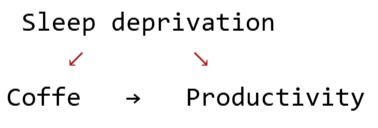


**Step 2: Without controlling for sleep deprivation, coffee and productivity appear to be related.**

In [ ]:
set.seed(1)

n <- 1000

sleep_deprivation <- rnorm(n)

coffee <- sleep_deprivation + rnorm(n)
productivity <- -sleep_deprivation + rnorm(n)

summary(lm(productivity ~ coffee))                # spurious relationship

**Step 3: Once we control for sleep deprivation, the relationship between coffee and productivity largely disappears.**

In [ ]:
summary(lm(productivity ~ coffee + sleep_deprivation))  # coffee effect disappears

Conclusion: A correlation between two variables may simply reflect the influence of a third factor, so without a clear causal framework, we cannot interpret it as evidence of a causal relationship.

## In-class activity:


In teams.

1.   Go to the form: https://forms.gle/kfguExsLK5Y1ov4m9
2.   Add your Team number.
3.   Add member's names and surnames.
4.   Each team submits ONLY one single form.
